# **Εργασία 2**

**Καθηγητής:**  Θεοδωρακόπουλος Ηλίας

**Φοιτητής:** Ιατρού Κωνσταντίνος 58071

# **Άσκηση 3**

**Κατεβάστε το Wine Dataset. Tα δεδομένα αυτά αποτελούν τα αποτελέσματα μιας χημικής ανάλυσης κρασιών από τρεις διαφορετικές καλλιεργητικές ποικιλίες {c1,c2,c3}, και περιλαμβάνουν τιμές για 13 χημικά συστατικά που μετρήθηκαν σε κάθε κρασί. Η πρώτη στήλη του αρχείου των δεδομένων περιλαμβάνει την ετικέτα της ποικιλίας του κάθε κρασιού, και οι επόμενες στήλες τις τιμές των συστατικών που μετρήθηκαν. Στόχος μας είναι να διερευνήσουμε το πρόβλημα της πρόβλεψης της ποικιλίας από τα αποτελέσματα της χημική ανάλυσης.**

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [20]:
file_data = np.loadtxt('wine.data', encoding=None, delimiter=',')

# Ερώτημα Α
**Θεωρείστε το υποσύνολο των δεδομένων που περιέχει τιμές μόνο για τα 5 πρώτα συστατικά και για τα κρασιά από τις ποικιλίες c2 και c3. Να χωρίσετε το παραπάνω σε σύνολο εκπαίδευσης, επικύρωσης και δοκιμής (training, validation & test sets) με αναλογία 50%, 25% και 25% αντίστοιχα, με τυχαία επιλογή δεδομένων και ίδια αναλογία μεταξύ των κλάσεων σε κάθε σύνολο.**

In [21]:
X = file_data[(file_data[:, 0]==2) | (file_data[:, 0]==3)]
y = X[:, 0]
X = X[:, 1:6]

Αρχικά εισάγω τα δεδομένα μόνο των κλάσεων c2 και c3 αλλά κρατώντας όλα τα χαρακτηριστικά. Στην συνέχεια κρατάω στην y μόνο τα labels των δεδομένων και στην συνέχεια τροποποιώ την Χ έτσι ώστε να κρατάει μόνο τα δεδομένα των 5 πρώτων χαρακτηριστικών (στήλες 1 έως και 5).

In [22]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.5, stratify=y, random_state=123)
validation_X, test_X, validation_y, test_y  = train_test_split(test_X, test_y, test_size=0.5, stratify=test_y, random_state=123)

Στην συνέχεια χωρίζω το σετ στα δύο για να κρατήσω το train set και στην συνέχεια το δεύτερο σετ το ξαναχωρίζω στα 2 ώστε το ένα μισό του μισού να το κρατήσω ως validation set και το δεύτερο ως test set.
Χρησιμοποιω το argument stratify=y ώστε να κρατήσει τις αναλογίες των δύο κλάσεων άθικτες και στα τρία σετ που δημιουργήθηκαν.
Ορίζω random_state=123 ώστε τα αποτελέσματα της συνάρτησης να είναι επαναλήψιμα(ο διαχωρισμός γίνεται ψευδοτυχαία όχι πραγματικά τυχαία).

# Ερώτημα Β

**Χρησιμοποιήστε γραμμικό SVM για να εκπαιδεύσετε ταξινομητή που να διαχωρίζει την κλάση c2 από τη c3. Χρησιμοποιήστε το validation set για να ρυθμίσετε την παράμετρο C (box constraint) κατάλληλα, και για την καλύτερη τιμή εφαρμόστε τον ταξινομητή που εκπαιδεύσατε στο test set. Τι σφάλμα ταξινόμησης πετύχατε?**

In [23]:
# Αρχικοποίηση του SVM με γραμμικό kernel
svm = SVC(kernel='linear')

# Ρύθμιση της παραμέτρου C χρησιμοποιώντας το Validation σετ
# Θα δοκιμάσουμε τιμές C διαφορετικής τάξης (εξού και η logspace) για να επιλέξουμε αυτή με την καλύτερη ακρίβεια.
C_values = np.logspace(-5, 5, 11)
best_accuracy = 0
bestC = 0

for C in C_values:
    svm.C = C
    svm.fit(train_X, train_y)
    validation_y_pred = svm.predict(validation_X)
    accuracy = accuracy_score(validation_y, validation_y_pred)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        bestC = C

# Ξαναεκπαιδεύουμε τα δεδομένα με βάση την καλύτερη τιμή του C που βρήκαμε
svm.C = bestC
svm.fit(train_X, train_y)

# Κάνουμε evaluation τον ταξινομητή δοκιμάζοντας τον στο test σετ το οποίο είχαμε αφήσει στην άκρη μέχρι στιγμής.
test_y_pred = svm.predict(test_X)
test_accuracy = accuracy_score(test_y, test_y_pred)

# Τυπώνουμε τα αποτελέσματα
print("Η καλύτερη τιμή για το box constraint είναι",bestC)
print("Η ακρίβεια του ταξινομητή στα άγνωστα δεδομένα του test set είναι",test_accuracy)

Η καλύτερη τιμή για το box constraint είναι 1000.0
Η ακρίβεια του ταξινομητή στα άγνωστα δεδομένα του test set είναι 0.8333333333333334


Αρχικά δημιουργούμε ένα αντικείμενο το οποίο θα περιέχει το SVM το οποίο θα εκπαιδεύσει τον ταξινομητή ο οποίος θα εφαρμοστεί στην συνέχεια σε άγνωστα για αυτόν δεδομένα για να τα κατατάξει σε μία από τις 2 κλάσεις.

Στην συνέχεια ορίζω έναν πίνακα (C_values) με διάφορες τιμές του box constraint (C) που θα ανήκουν σε διαφορετικές τάξεις μεγέθους [10^(-5), 10^(-4),...,10^4, 10^5] και αρχικοποιώ την μεταβλητή που θα εισάγω την καλύτερη ακρίβεια και την μεταβλητή που θα κρατήσω την καλύτερη τιμή για το box constrain (C) στο 0.

Μετά ορίζω έναν βρόχο που θα εκτελεστεί για κάθε τιμή στον πίνακα C_values μέσα στον οποίο θα εκπαιδεύουμε κάθε φορά τον ταξινομητή με βάση το train set που δημιουργήσμαμε προηγουμένος και αφού ολοκληρωθεί η εκπαίδευση θα δοκιμάζουμε τον ταξινομητή στο validation set για να δούμε τις προβλέψεις που θα κάνει. Αυτό το κάνει η συνάρτηση svm.predict(validation_x).

Στην συνέχεια χρησιμοποιούμε την συνάρτηση accuracy_socre(validation_y, validation_y_pred) η οποία στην ουσία συγκρίνει την validation_y που είναι τα labels των δεδομένων στο validation_x σετ με την validation_y_pred που στην ουσία είναι η πρόβλεψη που έκανε ο ταξηνομητής όταν του δόθηκε το validation σετ. Μετά την σύγκριση η συνάρτηση επιστρέφει την ακρίβεια της πρόβλεψης.

Αν η ακρίβεια που υπολογίστηκε είναι καλύτερη από την καλύτερη που έχει βρεθεί μέχρι εκείνη την στιγμή τότε την αντικαθιστά ως καλύτερη και κρατάει στην best_C την τιμή της box_costraint ως την πιο ιδανική που έχει υπολογιστεί μέχρι στιγμής.

Στο τέλος του βρόχου αφού έχει βρεθεί η καλύτερη τιμή του box costraint ξαναεπκαιδεύουμε τον ταξινομητή για την καλύτερη τιμή που είχαμε βρει και δοκιμάζουμε τον ταξινομητή στα δεδομένα του test set που του είναι τελείως άγνωστα για αυτόν και υπολογίζουμε την ακρίβεια που είχε σε αυτά τα δεδομένα ο ταξινομητής.

Εμείς όμως δεν θέλουμε να βρούμε την ακρίβεια αλλά το σφάλμα ταξινόμησης. Το υπολογίζουμε ως εξής:

Σφάλμα = 1 - Ακρίβεια

In [24]:
error = 1 - test_accuracy
print("Το σφάλμα ταξινόμησης είναι: ", error)

Το σφάλμα ταξινόμησης είναι:  0.16666666666666663


# Ερώτημα Γ

**Επαναλάβετε το προηγούμενο για 5 νέους τυχαιοποιημένους διαμερισμούς των δεδομένων, και υπολογίστε τη μέση τιμή και την τυπική απόκλιση του σφάλματος ταξινόμησης στο test set.**

In [25]:
# Επανάληψη της διαδικασίας για 5 διαφορετικούς τυχαιοποιημένους διαμερισμούς των δεδομένων

test_errors = []

for i in range(5):
    # Διαίρεση των δεδομένων σε σετ εκπαίδευσης, validation και test
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.5, stratify=y, random_state=i)
    validation_X, test_X, validation_y, test_y = train_test_split(test_X, test_y, test_size=0.5, stratify=test_y, random_state=i)

    # Εκπαίδευση και ρύθμιση της παραμέτρου C του γραμμικού SVM
    best_error = float('inf')
    bestC = 0

    for C in C_values:
        svm.C = C
        svm.fit(train_X, train_y)
        y_val_pred = svm.predict(validation_X)
        error = 1 - accuracy_score(validation_y, y_val_pred)
        if error < best_error:
            best_error = error
            bestC = C

    # Εκπαίδευση του καλύτερου C στον SVM που θα εκπαιδεύσει τον ταξινομητή
    svm.C = bestC
    print("Επανάληψη", i, "-> Καλύτερη τιμή για το Box Constraint:", bestC)
    svm.fit(train_X, train_y)

    # Υπολογσιμός σφάλματος του ταξινομητή στο test set
    y_test_pred = svm.predict(test_X)
    test_error = 1 - accuracy_score(test_y, y_test_pred)
    test_errors.append(test_error)

# Υπολογισμός της μέσης τιμής και της τυπικής απόκλισης του σφάλματος ταξινόμησης
mean_error = np.mean(test_errors)
std_error = np.std(test_errors)

print("\nΜέση τιμή σφάλματος:", mean_error)
print("Τυπική Απόκλιση των ακριβειών που υπολογίστηκαν:", std_error)

Επανάληψη 0 -> Καλύτερη τιμή για το Box Constraint: 10000.0
Επανάληψη 1 -> Καλύτερη τιμή για το Box Constraint: 1.0
Επανάληψη 2 -> Καλύτερη τιμή για το Box Constraint: 0.1
Επανάληψη 3 -> Καλύτερη τιμή για το Box Constraint: 100000.0
Επανάληψη 4 -> Καλύτερη τιμή για το Box Constraint: 10.0

Μέση τιμή σφάλματος: 0.15999999999999998
Τυπική Απόκλιση των ακριβειών που υπολογίστηκαν: 0.05333333333333332


Για την επίλυση αυτού το ερωτήματος αρχικά δημιουργούμε ένα βρόχο 5 επαναλήψεων στον οποίο κάνουμε 5 ψευδοτυχαίους διαμερισμούς στους οποίους ορίσαμε seed (random_state) για να είναι επαναλήψιμα τα αποτελέσματα.

Αρχικοποιώ το best_error στο άπειρο και το καλύτερο C στο 0. Δοκιμάζω σε κάθε διαμερισμό όλες τις τάξεις του C που έχω στον πίνακα C_values και κρατάω την καλύτερη πάντοτε.

Στην συνέχεια τυπώνω ποια τιμή του box constraint ήταν η καλύτερη σε κάθε επανάληψη και την χρησιμοποιώ για να εκπαιδεύσω τον ταξινομητή με SVM.

Αφού γίνουν αυτά εφαρμόζω στον ταξινομητή τα δεδομένα του test set για να υπολογίσω το σφάλμα του. (Στην ουσία υπολογίζω την ακρίβεια με την συνάρτηση accuracy_score() που δίνεται από την βιβλιοθήκη sklearn και την τιμή αυτή την αφαιρώ από το 1)

Τέλος κάνω append το σφάλμα στον πίνακα που κρατάω τα καλύτερα σφάλματα κάθε επανάληψης και τυπώνω την μέση τιμή τους και την τυπική απόκλιση τους.

# Ερώτημα Δ

**Επαναλάβετε το Γ για μη-γραμμικό SVM δοκιμάζοντας διάφορες συναρτήσεις πυρήνα (RBF, polynomial κλπ). Τι σφάλμα πετύχατε? Ποιος είναι ο καλύτερος ταξινομητής για το πρόβλημα? Σχολιάστε.**


In [26]:
# Αρχικοποίηση των παραμέτρων και των λιστών για την αποθήκευση των αποτελεσμάτων
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
best_C_per_kernel = {kernel: [] for kernel in kernels}
best_error_per_kernel = {kernel: [] for kernel in kernels}

# Επανάληψη για 5 διαφορετικούς τυχαιοποιημένους διαμερισμούς των δεδομένων
for i in range(5):
    # Διαίρεση των δεδομένων σε σετ εκπαίδευσης, επικύρωσης και δοκιμής
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, stratify=y, random_state=i)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=i)

    for kernel in kernels:
        # Ρύθμιση του grid search για τον SVM με τον συγκεκριμένο πυρήνα
        grid_search = GridSearchCV(SVC(kernel=kernel), {'C': C_values})
        grid_search.fit(X_train, y_train)

        # Αποθήκευση της καλύτερης τιμής C και της ακρίβειας για αυτή την τιμή
        best_C = grid_search.best_params_['C']
        best_model = grid_search.best_estimator_
        best_model.fit(X_train, y_train)
        best_error = 1 - best_model.score(X_test, y_test) #best_error

        best_C_per_kernel[kernel].append(best_C)
        best_error_per_kernel[kernel].append(best_error)


best_C_per_kernel, best_error_per_kernel

print("Linear Kernel")
for i in range(5):
  print('Διαμερισμός', i+1, "-> Best C =", best_C_per_kernel['linear'][i])

print("-----------------------------------------------------")

print("Radial Kernel")
for i in range(5):
  print('Διαμερισμός', i+1, "-> Best C =", best_C_per_kernel['rbf'][i])

print("-----------------------------------------------------")

print("Polynomial Kernel")
for i in range(5):
  print('Διαμερισμός', i+1, "-> Best C =", best_C_per_kernel['poly'][i])

print("-----------------------------------------------------")

print("Sigmoid Kernel")
for i in range(5):
  print('Διαμερισμός', i+1, "-> Best C =", best_C_per_kernel['sigmoid'][i])

print("-----------------------------------------------------")

print("\nΜΕΣΕΣ ΤΙΜΕΣ ΣΦΑΛΜΑΤΟΣ")
for i in kernels:

  print(i, ": Σφάλμα=", np.mean(best_error_per_kernel[i]), "|   Τυπική απόκλιση=", np.std(best_error_per_kernel[i]))


Linear Kernel
Διαμερισμός 1 -> Best C = 1.0
Διαμερισμός 2 -> Best C = 0.1
Διαμερισμός 3 -> Best C = 1000.0
Διαμερισμός 4 -> Best C = 1.0
Διαμερισμός 5 -> Best C = 1.0
-----------------------------------------------------
Radial Kernel
Διαμερισμός 1 -> Best C = 1000.0
Διαμερισμός 2 -> Best C = 10000.0
Διαμερισμός 3 -> Best C = 10000.0
Διαμερισμός 4 -> Best C = 1000.0
Διαμερισμός 5 -> Best C = 1000.0
-----------------------------------------------------
Polynomial Kernel
Διαμερισμός 1 -> Best C = 1000.0
Διαμερισμός 2 -> Best C = 1000.0
Διαμερισμός 3 -> Best C = 100.0
Διαμερισμός 4 -> Best C = 100000.0
Διαμερισμός 5 -> Best C = 100.0
-----------------------------------------------------
Sigmoid Kernel
Διαμερισμός 1 -> Best C = 1e-05
Διαμερισμός 2 -> Best C = 10.0
Διαμερισμός 3 -> Best C = 1e-05
Διαμερισμός 4 -> Best C = 1e-05
Διαμερισμός 5 -> Best C = 1000.0
-----------------------------------------------------

ΜΕΣΕΣ ΤΙΜΕΣ ΣΦΑΛΜΑΤΟΣ
linear : Σφάλμα= 0.1933333333333333 |   Τυπική απόκλιση

Στο ερώτημα Δ οι συνδιασμοί των παραμέτρων που πρέπει να δοκιμαστούν αυξάνονται σε μεγάλο βαθμό από την άποψη των υπολογισμών που πρέπει να γίνουν.
Δηλαδή για κάθε έναν από τους 5 διαφορετικούς τυχαιοποιημένους διαμερισμούς, οι οποίοι είναι ίδιοι με αυτούς του ερωτήματος Γ, θέλουμε να δοκιμάσουμε και διαφορετικούς Kernel.

Αρχικά ορίσαμε τα 4 σχήματα των Kernel που θέλουμε να συγκρίνουμε. Επειδή οι συνδιασμοί αυξήθηκαν γεωμετρικά αποφάσισα να κάνω την αναζήτηση με την χρήση αντικειμένου τύπου GridSearchCV στο οποίο ορίζουμε τον Kernel του SVM και βρίσκει το C για το οποίο ο ταξινομητής έχει την καλύτερη ακρίβεια.

Η κλάση GridSearchCV περιέχει κάποιες συναρτήσεις που βοηθάνε στην δοκιμή όλων αυτών των συνδιασμών και στην επιλογή του καλύτερου από αυτούς. Την χρησιμοποιούμε γιατί γλιτώνει από την υλοποίηση μεγάλου σε μήκους κώδικα που θα χρειαζόταν να υλοποιηθεί αν δοκιμάζαμε μόνοι μας τους συνδιασμούς.

Δημιουργούμε και λεξικά που για κάθε kernel θα έχουν μία λιστα με την καλύτερη τιμή του C για κάθε έναν από τους 5 ψευδοτυχαίους διαμερισμούς.

Σε κάθε επανάληψη του βρόχου και για κάθε kernel κρατάμε στο best_model τον καλύτερο SVM για τον διαμερισμό της επανάληψης. Πάνω στον ταξινομήτή που εκαιδεύεται από τον συγκεκριμένο SVM δοκιμάζουμε το test set και υπολογίζουμε το accuracy του καλύτερου SVM της επανάληψης.

Μετά την ολοκλήρωση του βρόχου έχουμε στην ουσία τα λεξικά best_C_per_kernel και best_error_per_kernel που περιέχει τις 5 καλύτερες τιμές του C για κάθε επανάληψη για κάθε kernel και τις ακρίβειες που έχει ο ταξινομητής για κάθε kernel σε κάθε μία από τις 5 επαναλήψεις.

Τέλος τυπώνω τις καλύτερες τιμές του C για κάθε kernel σε κάθε επανάληψη και τις μέσες τιμές και τις αποκλίσεις των σφαλμάτων για κάθε kernel.

*Σημείωση: Εδώ δεν δοκίμασα διαφορετικούς βαθμούς πολυωνύμου γιατί θα αυξανόταν πάρα πολύ το υπολογιστικό κόστος και θα καθυστερούσε πολύ για να τερματίσει το συγκεκριμένο cell.*

# Ερώτημα Ε

**Χρησιμοποιήστε γραμμικό SVM για να εκπαιδεύσετε ταξινομητές για το πλήρες πρόβλημα των 3 κλάσεων, με την προσέγγιση ένας-εναντίον-ενός (one-vs-one) και καταμέτρηση ψήφων. Μπορείτε να αξιοποιήσετε τις σχετικές αυτοματοποιημένες λειτουργίες που έχουν κάποιες βιβλιοθήκες SVM. Θέτοντας το C=1 και ακολουθώντας πρωτόκολλο 5-fold cross validation, να υπολογίστε τη μέση τιμή του σφάλματος ταξινόμησης χρησιμοποιώντας α) τα 5 πρώτα χαρακτηριστικά όπως και παραπάνω, και β) όλα τα διαθέσιμα χαρακτηριστικά. Σχολιάστε τα αποτελέσματα.
Υπολογίστε για κάθε περίπτωση τον πίνακα σύγχυσης (confusion matrix) της ταξινόμησης και σχολιάστε ποιες κλάσεις ομοιάζουν περισσότερο.**

In [27]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [28]:
all_X_all_feat = file_data[:, 1:] #Ολες οι κλάσεις και όλα τα χαρακτηριστικά
labels = file_data[:, 0] # Οι ετικέτες
all_X_5_feat = file_data[:, 1:6] #Ολες οι κλάσεις αλλά μόνο τα 5 πρώτα χαρακτηριστικά

In [29]:
def conf_matrix_calc(data_X, labels):
  OneVsOne_Model = OneVsOneClassifier(SVC(kernel='linear', C=1))

  # Εκτίμηση σφλαματος με 5-fold cross-validation
  errors = 1 - cross_val_score(OneVsOne_Model, data_X, labels, cv=5, scoring='accuracy')
  mean_error = errors.mean()
  error_std = errors.std()

  print("Το μέσο σφάλμα ταξινόμησης είναι:", mean_error)
  print("Η τυπική απόκλιση των σφαλμάτων είναι:", error_std)

  y = cross_val_predict(OneVsOne_Model, data_X, labels, cv=5)

  conf_matr = confusion_matrix(labels, y)

  ConfusionMatrixDisplay.from_predictions(labels, y)
  plt.title("Πίνακας σύγχυσης για {} χαρακτηριστικά και {} κλάσεις".format(data_X.shape[1], len(np.unique(labels))))
  plt.show()

Η συνάρτηση conf_matrix_calc(data_X, labels) παίρνει ως παραμέτρους εισόδου τα δεδομένα (data_X) και τα labels τους.

Αρχικά ορίζω έναν ταξινομητή One vs One που θα εκπαιδευτεί με ένα SVM με γραμμικό kernel και box constraint C=1.

Στην συνέχεια υπολογίζω τα σφάλματα του ταξινομητή ο οποίος εκπαιδεύτηκε με 5-fold cross validation. Από τα σφάλματα υπολογίζω την μέση τιμή τους και την τυπική τους απόκλιση και τα τυπώνω.

Στην συνέχεια χρησιμοποιώ τον ταξινομητή για να κάνω prediction στα δεδομένα του test set και συγκρίνοντας τα labels με το prediction και δημιουργώ τον πίνακα σύγχυσης και τον εμφανίζω.

*Σημείωση: Αρχικά ήθελα να τα τυπώσω σε μία εικόνα με 2 subplots, αλλά λόγω αρκετών τεχνικών δυσκολιών και έλλειψης χρόνου κατέληξα να φτιάξω μία συνάρτηση που θα υπολογίζει το μέσο σφάλμα, την τυπική απόκλιση και τον πίνακα σύγχυσης σε διάγραμμα*

Το μέσο σφάλμα ταξινόμησης είναι: 0.18523809523809523
Η τυπική απόκλιση των σφαλμάτων είναι: 0.06318098396427421


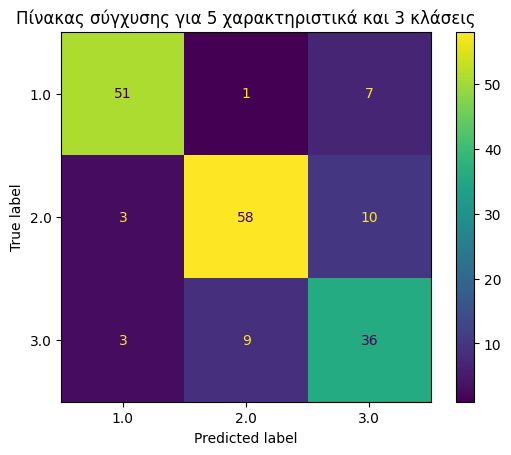

In [30]:
conf_matrix_calc(all_X_5_feat, labels)

Το μέσο σφάλμα ταξινόμησης είναι: 0.0388888888888889
Η τυπική απόκλιση των σφαλμάτων είναι: 0.041573970964154924


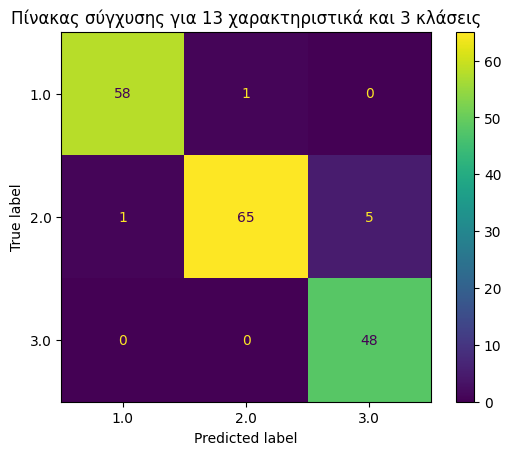

In [31]:
conf_matrix_calc(all_X_all_feat, labels)